
## Clarified Objective and Methodology

This notebook performs an **exploratory analysis of inter-dataset visual similarity**.
A **single, common backbone** (ResNet-50 pre-trained on ImageNet) is used **without any fine-tuning**
to extract embeddings from images coming from different datasets (e.g., COCO, DOTA, DIOR).

All datasets are processed by the **same frozen network**, ensuring that the resulting embeddings
lie in a shared feature space and are therefore directly comparable.

Dimensionality reduction techniques (PCA and t-SNE) are used **only for visualization** purposes.
This analysis provides qualitative intuition about potential domain shifts, and does **not**
evaluate object detection performance.


In this study, we analyze the visual similarity between several image datasets by projecting them into a shared feature space using a common backbone network. Specifically, we employ a ResNet-50 model pre-trained on ImageNet as a fixed feature extractor to generate high-dimensional embeddings for images from different datasets, including COCO, DOTA, and DIOR. By using the same pre-trained backbone for all datasets, we ensure that the extracted representations are directly comparable and not biased by dataset-specific training. These embeddings are then reduced to a low-dimensional space using PCA followed by t-SNE, allowing for qualitative visualization of their distribution. This approach provides an exploratory analysis of inter-dataset similarity and offers intuition about potential domain shifts, which are known to impact cross-domain transfer performance in object detection tasks. While this analysis does not measure task performance directly, it serves as a complementary perspective to performance-based evaluations reported in the literature.

In [21]:
import torch, torchvision.transforms
from torchvision.models import resnet50, ResNet50_Weights

In [22]:
import requests
from PIL import Image

#test
'''url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)'''

'url = "http://images.cocodataset.org/val2017/000000039769.jpg"\nimage = Image.open(requests.get(url, stream=True).raw)'

## Dataset Loading from Hugging Face

Datasets are loaded directly from Hugging Face repositories.
This avoids manual downloads and ensures reproducibility.
Only image data is used; annotations are intentionally ignored.


In [23]:
from datasets import load_dataset, Dataset
from itertools import islice

def load_fewshot_dataset(
    dataset_name,
    k,
    buffer_size=100,
    seed=42,
    split="train",
):
    # streaming (pas de download complet)
    stream_ds = load_dataset(
        dataset_name,
        split=split,
        streaming=True
    )

    # shuffle streaming
    stream_ds = stream_ds.shuffle(
        buffer_size=buffer_size,
        seed=seed
    )

    # extraction few-shot
    fewshot_list = list(islice(stream_ds, k))

    # conversion en Dataset classique
    return Dataset.from_list(fewshot_list)


In [24]:
'''

buffer_size = 200
seed = 42

coco_bg_ds = load_dataset("HichTala/coco-background", split="train", streaming=True)
coco_bg_ds = coco_bg_ds.shuffle(buffer_size=buffer_size, seed=seed)

dota_bg_ds = load_dataset("HichTala/dota-background", split="train", streaming=True)
dota_bg_ds = dota_bg_ds.shuffle(buffer_size=buffer_size, seed=seed)

dior_ds = load_dataset("HichTala/dior", split="train", streaming=True)
dior_ds = dior_ds.shuffle(buffer_size=buffer_size, seed=seed)

coco_ds = load_dataset("HichTala/coco", split="train", streaming=True)
coco_ds = coco_ds.shuffle(buffer_size=buffer_size, seed=seed)

dota_ds = load_dataset("HichTala/dota", split="train", streaming=True)
dota_ds = dota_ds.shuffle(buffer_size=buffer_size, seed=seed)

deepfruits_ds = load_dataset("HichTala/deepfruits", split="train", streaming=True)
deepfruits_ds = deepfruits_ds.shuffle(buffer_size=buffer_size, seed=seed)

xview_ds = load_dataset("HichTala/xview", split="train", streaming=True)
xview_ds = xview_ds.shuffle(buffer_size=buffer_size, seed=seed)

oktoberfest_ds = load_dataset("HichTala/oktoberfest", split="train", streaming=True)
oktoberfest_ds = oktoberfest_ds.shuffle(buffer_size=buffer_size, seed=seed)
'''



'\n\nbuffer_size = 200\nseed = 42\n\ncoco_bg_ds = load_dataset("HichTala/coco-background", split="train", streaming=True)\ncoco_bg_ds = coco_bg_ds.shuffle(buffer_size=buffer_size, seed=seed)\n\ndota_bg_ds = load_dataset("HichTala/dota-background", split="train", streaming=True)\ndota_bg_ds = dota_bg_ds.shuffle(buffer_size=buffer_size, seed=seed)\n\ndior_ds = load_dataset("HichTala/dior", split="train", streaming=True)\ndior_ds = dior_ds.shuffle(buffer_size=buffer_size, seed=seed)\n\ncoco_ds = load_dataset("HichTala/coco", split="train", streaming=True)\ncoco_ds = coco_ds.shuffle(buffer_size=buffer_size, seed=seed)\n\ndota_ds = load_dataset("HichTala/dota", split="train", streaming=True)\ndota_ds = dota_ds.shuffle(buffer_size=buffer_size, seed=seed)\n\ndeepfruits_ds = load_dataset("HichTala/deepfruits", split="train", streaming=True)\ndeepfruits_ds = deepfruits_ds.shuffle(buffer_size=buffer_size, seed=seed)\n\nxview_ds = load_dataset("HichTala/xview", split="train", streaming=True)\nxvi

In [25]:
few_shot_n = 50
buffer_size = 100
seed = 42


In [26]:
coco_bg_ds = load_fewshot_dataset(
    "HichTala/coco-background",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

dota_bg_ds = load_fewshot_dataset(
    "HichTala/dota-background",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

dior_ds = load_fewshot_dataset(
    "HichTala/dior",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

coco_ds = load_fewshot_dataset(
    "HichTala/coco",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

dota_ds = load_fewshot_dataset(
    "HichTala/dota",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

deepfruits_ds = load_fewshot_dataset(
    "HichTala/deepfruits",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

xview_ds = load_fewshot_dataset(
    "HichTala/xview",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)

oktoberfest_ds = load_fewshot_dataset(
    "HichTala/oktoberfest",
    few_shot_n,
    buffer_size=buffer_size,
    seed=seed,
)


In [27]:
'''from itertools import islice

K = 20

fewshot_coco_bg = list(islice(coco_bg_ds, K))
fewshot_dota_bg = list(islice(dota_bg_ds, K))
fewshot_dior = list(islice(dior_ds, K))
fewshot_coco = list(islice(coco_ds, K))
fewshot_dota = list(islice(dota_ds, K))
fewshot_deepfruits = list(islice(deepfruits_ds, K))
fewshot_xview = list(islice(xview_ds, K))
fewshot_oktoberfest = list(islice(oktoberfest_ds, K))'''

'from itertools import islice\n\nK = 20\n\nfewshot_coco_bg = list(islice(coco_bg_ds, K))\nfewshot_dota_bg = list(islice(dota_bg_ds, K))\nfewshot_dior = list(islice(dior_ds, K))\nfewshot_coco = list(islice(coco_ds, K))\nfewshot_dota = list(islice(dota_ds, K))\nfewshot_deepfruits = list(islice(deepfruits_ds, K))\nfewshot_xview = list(islice(xview_ds, K))\nfewshot_oktoberfest = list(islice(oktoberfest_ds, K))'

## test figer les seeds few shot 

In [28]:
'''import json
json.dump(fewshot_coco, open("fewshot_coco.json", "w"))
'''

'import json\njson.dump(fewshot_coco, open("fewshot_coco.json", "w"))\n'

## Common Backbone: ResNet-50 (ImageNet)

We use a ResNet-50 model pre-trained on ImageNet as a common backbone for all datasets.
The classification head is removed in order to extract global image embeddings.
The network is kept frozen and used only in inference mode.

In [29]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

In [30]:
model

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = model.to(device)

print("Using device:", device)


Using device: mps


In [31]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)

model.fc = nn.Identity()

model.eval()
model.to(device)
preprocess = weights.transforms()
print("Model.fc =", model.fc)



Model.fc = Identity()


## Device Selection

Computation is performed on the Apple MPS backend when available.
If MPS is not available, the CPU is used as a fallback.
This ensures compatibility across different hardware configurations.


## 3. Embedding Extraction Function

## Embedding Extraction Function

This function extracts global image embeddings by forwarding batches of images
through the frozen ResNet-50 backbone.
The output corresponds to the 2048-dimensional representation obtained after
global average pooling, before the classification layer.


In [32]:
import torch
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def extract_embeddings(model, dataloader, device):
    """
    Extract image embeddings using a frozen ResNet-50 backbone.

    Args:
        model (torch.nn.Module): ResNet-50 with fc = Identity()
        dataloader (DataLoader): DataLoader returning (image, _)
        device (str): 'mps' or 'cpu'

    Returns:
        np.ndarray: Array of shape (N, 2048)
    """
    model.eval()
    embeddings = []

    for images, _ in tqdm(dataloader, desc="Extracting embeddings"):
        images = images.to(device)

        # Forward pass
        feats = model(images)   # shape: [B, 2048]

        embeddings.append(feats.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    return embeddings




## 4. Dataset Loading (Few-Shot)

## Few-Shot Sampling

A few-shot protocol is adopted by randomly sampling a limited number of images
from each dataset.
This simulates data-scarce scenarios and ensures a balanced comparison
between datasets of different sizes.


In [33]:
few_shot_n = 50

coco_bg_sample = coco_bg_ds.shuffle(seed=42).select(range(few_shot_n))
dota_bg_sample = dota_bg_ds.shuffle(seed=42).select(range(few_shot_n))
dior_sample = dior_ds.shuffle(seed=42).select(range(few_shot_n))
coco_sample = coco_ds.shuffle(seed=42).select(range(few_shot_n))
dota_sample = dota_ds.shuffle(seed=42).select(range(few_shot_n))
deepfruits_sample = deepfruits_ds.shuffle(seed=42).select(range(few_shot_n))
xview_sample = xview_ds.shuffle(seed=42).select(range(few_shot_n))
oktoberfest_sample = oktoberfest_ds.shuffle(seed=42).select(range(few_shot_n))


In [34]:
'''few_shot_n = 50

coco_bg_sample = fewshot_coco_bg.shuffle(seed=42).select(range(few_shot_n))
dota_bg_sample = fewshot_dota_bg.shuffle(seed=42).select(range(few_shot_n))
dior_sample = fewshot_dior.shuffle(seed=42).select(range(few_shot_n))
coco_sample = fewshot_coco.shuffle(seed=42).select(range(few_shot_n))
dota_sample = fewshot_dota.shuffle(seed=42).select(range(few_shot_n))
deepfruits_sample = fewshot_deepfruits.shuffle(seed=42).select(range(few_shot_n))
xview_sample = fewshot_xview.shuffle(seed=42).select(range(few_shot_n))
oktoberfest_sample = fewshot_oktoberfest.shuffle(seed=42).select(range(few_shot_n))'''

'few_shot_n = 50\n\ncoco_bg_sample = fewshot_coco_bg.shuffle(seed=42).select(range(few_shot_n))\ndota_bg_sample = fewshot_dota_bg.shuffle(seed=42).select(range(few_shot_n))\ndior_sample = fewshot_dior.shuffle(seed=42).select(range(few_shot_n))\ncoco_sample = fewshot_coco.shuffle(seed=42).select(range(few_shot_n))\ndota_sample = fewshot_dota.shuffle(seed=42).select(range(few_shot_n))\ndeepfruits_sample = fewshot_deepfruits.shuffle(seed=42).select(range(few_shot_n))\nxview_sample = fewshot_xview.shuffle(seed=42).select(range(few_shot_n))\noktoberfest_sample = fewshot_oktoberfest.shuffle(seed=42).select(range(few_shot_n))'

In [35]:
from PIL import Image
import numpy as np

def hf_dataset_to_pil(dataset):
    images = []
    for item in dataset:
        # Dans ces datasets, l'image est stockée dans la colonne "image"
        img = item["image"]
        if isinstance(img, Image.Image):
            images.append(img.convert("RGB"))
        else:
            images.append(Image.fromarray(img).convert("RGB"))
    return images

coco_bg_imgs = hf_dataset_to_pil(coco_bg_sample)
dota_bg_imgs = hf_dataset_to_pil(dota_bg_sample)
dior_imgs = hf_dataset_to_pil(dior_sample)
dota_imgs = hf_dataset_to_pil(dota_sample)
coco_imgs = hf_dataset_to_pil(coco_sample)
oktoberfest_imgs= hf_dataset_to_pil(oktoberfest_sample)
xview_imgs = hf_dataset_to_pil(xview_sample)
deepfruits_imgs = hf_dataset_to_pil(deepfruits_sample)



## Dataset Wrapper for PyTorch

A custom PyTorch Dataset is defined to convert the sampled images
into tensors and apply the required preprocessing.
Dummy labels are returned to comply with the DataLoader interface.


In [36]:
from torch.utils.data import DataLoader, Dataset

class FewShotListDataset(Dataset):
    def __init__(self, pil_images, transform):
        self.images = pil_images
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.transform(self.images[idx]), 0

def fewshot_loader(pil_list, batch_size=8):
    return DataLoader(FewShotListDataset(pil_list, preprocess), batch_size=batch_size)


## 9. DataLoader Construction

DataLoaders are created to efficiently batch images and iterate over
the datasets during embedding extraction.
Shuffling is disabled to preserve deterministic ordering.


In [37]:
batch_size = 8

dior_dataset = FewShotListDataset(dior_imgs, preprocess)
dior_loader = DataLoader(dior_dataset, batch_size=batch_size, shuffle=False)

coco_bg_dataset = FewShotListDataset(coco_bg_imgs, preprocess)
coco_bg_loader = DataLoader(coco_bg_dataset, batch_size=batch_size, shuffle=False)

dota_bg_dataset = FewShotListDataset(dota_bg_imgs, preprocess)
dota_bg_loader = DataLoader(dota_bg_dataset, batch_size=batch_size, shuffle=False)

dota_dataset = FewShotListDataset(dota_imgs, preprocess)
dota_loader = DataLoader(dota_dataset, batch_size=batch_size, shuffle=False)

coco_dataset = FewShotListDataset(coco_imgs, preprocess)
coco_loader = DataLoader(coco_dataset, batch_size=batch_size, shuffle=False)

oktoberfest_dataset = FewShotListDataset(oktoberfest_imgs, preprocess)
oktoberfest_loader = DataLoader(oktoberfest_dataset, batch_size=batch_size, shuffle=False)

xview_dataset = FewShotListDataset(xview_imgs, preprocess)
xview_loader = DataLoader(xview_dataset, batch_size=batch_size, shuffle=False)

deepfruits_dataset = FewShotListDataset(deepfruits_imgs, preprocess) 
deepfruits_loader = DataLoader(deepfruits_dataset, batch_size=batch_size, shuffle=False)

print(len(dior_loader.dataset))


50


## 5. Embedding Extraction

## Embedding Extraction

Image embeddings are extracted for each dataset using the same frozen backbone.
Each image is mapped to a 2048-dimensional feature vector,
allowing direct comparison across datasets.


## Chosen Method

create_feature_extractor is useful for accessing intermediate feature maps, but for our analysis we only require the final global representation before classification, which is directly obtained by removing the classification head of the network.

In [38]:
emb_coco_bg = extract_embeddings(model, coco_bg_loader, device)
emb_dota_bg = extract_embeddings(model, dota_bg_loader, device)
emb_dior = extract_embeddings(model, dior_loader, device)
emb_coco = extract_embeddings(model, coco_loader, device)
emb_dota = extract_embeddings(model, dota_loader, device)
emb_oktoberfest = extract_embeddings(model, oktoberfest_loader, device)
emb_xview = extract_embeddings(model, xview_loader, device)
emb_deepfruits = extract_embeddings(model, deepfruits_loader, device)


print(emb_dior.shape)

embeddings_dict = {}

embeddings_dict["COCO"] = emb_coco
embeddings_dict["DOTA"] = emb_dota
embeddings_dict["DIOR"] = emb_dior
embeddings_dict["COCO_BG"] = emb_coco_bg
embeddings_dict["DOTA_BG"] = emb_dota_bg
embeddings_dict["OKTOBERFEST"] = emb_oktoberfest
embeddings_dict["XVIEW"] = emb_xview
embeddings_dict["DEEPFRUITS"] = emb_deepfruits

Extracting embeddings: 100%|██████████| 7/7 [00:00<00:00, 16.20it/s]

(50, 2048)


## Test Part

In [39]:
'''import torchvision

inputs = torchvision.transforms.ToTensor()(image)'''

'import torchvision\n\ninputs = torchvision.transforms.ToTensor()(image)'

In [40]:
'''from torch import nn

model.fc = nn.Linear(in_features=2048, out_features=2, bias=True)'''

'from torch import nn\n\nmodel.fc = nn.Linear(in_features=2048, out_features=2, bias=True)'

In [41]:
'''inputs = inputs.unsqueeze(0)'''

'inputs = inputs.unsqueeze(0)'

In [42]:
'''outputs = model(inputs)'''

'outputs = model(inputs)'

In [43]:
'''outputs.shape'''

'outputs.shape'

In [44]:
'''from torchvision.models.feature_extraction import create_feature_extractor

feature_extractor = create_feature_extractor(model, {'layer1': 'feat1', 'layer2': 'feat2', 'layer3': 'feat3', 'layer4': 'feat4'})'''

"from torchvision.models.feature_extraction import create_feature_extractor\n\nfeature_extractor = create_feature_extractor(model, {'layer1': 'feat1', 'layer2': 'feat2', 'layer3': 'feat3', 'layer4': 'feat4'})"

In [45]:
'''feature_extractor(inputs)['feat4'].shape'''

"feature_extractor(inputs)['feat4'].shape"

In [46]:
'''nn.Flatten()(feature_extractor(inputs)['feat4']).shape'''

"nn.Flatten()(feature_extractor(inputs)['feat4']).shape"

## 6. Dimensionality Reduction and Visualization

## Dimensionality Reduction

Principal Component Analysis (PCA) is first applied to reduce noise
and stabilize the embedding space.
The reduced embeddings are then projected to two dimensions using t-SNE
for visualization purposes.


In [47]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"


In [48]:
import numpy as np

X = []
labels = []

for dataset_name, emb in embeddings_dict.items():
    X.append(emb)
    labels.extend([dataset_name] * emb.shape[0])

X = np.vstack(X)
labels = np.array(labels)

print("X shape:", X.shape)
print("Labels shape:", labels.shape)


X shape: (400, 2048)
Labels shape: (400,)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)



In [50]:
import numpy as np

print("NaN:", np.isnan(X_norm).any())
print("Inf:", np.isinf(X_norm).any())


NaN: False
Inf: False


In [51]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=min(5, X_norm.shape[0] - 1),
    init="random",
    learning_rate=50,
    method="barnes_hut",
    random_state=0
)

X_tsne = tsne.fit_transform(X_norm)

print(X_tsne.shape)



(400, 2)


In [52]:
'''from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_pca = PCA(n_components=15, random_state=0).fit_transform(X)

X_tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=0,
    init="pca"
).fit_transform(X_pca)'''


'from sklearn.decomposition import PCA\nfrom sklearn.manifold import TSNE\n\nX_pca = PCA(n_components=15, random_state=0).fit_transform(X)\n\nX_tsne = TSNE(\n    n_components=2,\n    perplexity=10,\n    random_state=0,\n    init="pca"\n).fit_transform(X_pca)'

In [53]:
'''X = np.vstack([emb_coco, emb_dota, emb_dior])
labels = ["COCO"]*len(emb_coco) + ["DOTA"]*len(emb_dota) + ["DIOR"]*len(emb_dior)

X_pca = PCA(n_components=50, random_state=0).fit_transform(X)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_pca)'''
'''
X = np.vstack([emb_dior])
labels =["DIOR"]*len(emb_dior)

X_pca = PCA(n_components=50, random_state=0).fit_transform(X)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_pca)'''

'\nX = np.vstack([emb_dior])\nlabels =["DIOR"]*len(emb_dior)\n\nX_pca = PCA(n_components=50, random_state=0).fit_transform(X)\nX_tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_pca)'

## Visualization

The 2D t-SNE embeddings are visualized to analyze the distribution,
overlap, and separation between datasets.
This qualitative analysis provides intuition about inter-dataset
visual similarity and potential domain shifts.


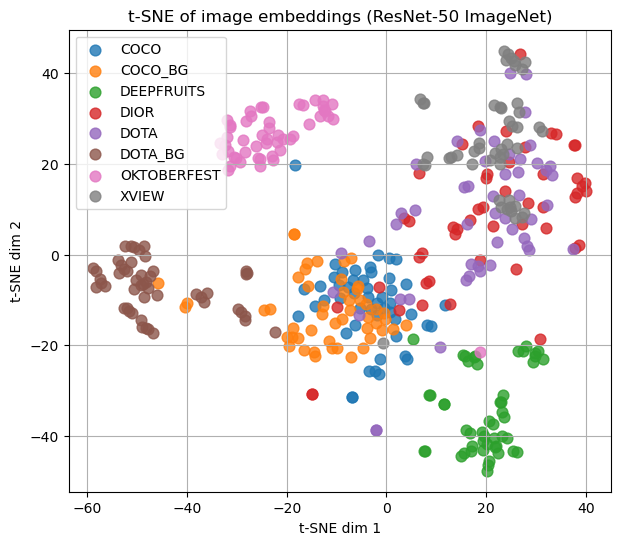

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for dataset_name in np.unique(labels):
    idx = labels == dataset_name
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=dataset_name,
        s=60,
        alpha=0.8
    )

plt.title("t-SNE of image embeddings (ResNet-50 ImageNet)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.grid(True)
plt.show()


In [55]:
'''import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, alpha=0.7)
plt.title("t-SNE of Few-Shot Embeddings")
plt.show()'''


'import matplotlib.pyplot as plt\nimport seaborn as sns\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, alpha=0.7)\nplt.title("t-SNE of Few-Shot Embeddings")\nplt.show()'

## Notes and Limitations

- This study is exploratory and qualitative in nature.
- No fine-tuning or task-specific training is performed.
- Detection performance metrics (e.g., mAP) are not evaluated.
- Observations should be interpreted as representation-level insights.
